Intrusion Detection (Smartphone Sensor Data)

**What this notebook does**
1. Loads your CSV sensor logs (uploaded files)
2. Cleans & merges data
3. Creates fixed-size windows and extracts ML features
4. Trains a **Hybrid IDS**:
   - Stage A: **Isolation Forest** (anomaly detector, trained on owner only)
   - Stage B: **Logistic Regression** (lightweight classifier for mobile)
5. Evaluates metrics + saves models for app integration

> **Note:** CICIDS2017/NSL-KDD are **network** intrusion datasets. Your files are **smartphone sensor** datasets, which are the correct match for your dissertation title.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

DATA_FILES = [
    'SENSORDATA.csv',
    'Sensors.csv',
    'UserInfo.csv',
]

for p in DATA_FILES:
    print(p, Path(p).exists())


SENSORDATA.csv True
Sensors.csv True
UserInfo.csv True


In [2]:
def load_and_clean_sensor_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Drop accidental index col
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    # Standardize datetime
    if 'Date_time' in df.columns:
        df['Date_time'] = pd.to_datetime(df['Date_time'], errors='coerce', dayfirst=False)

    # Battery to numeric (e.g., '89%')
    if 'BATTERY_LEVEL' in df.columns:
        df['BATTERY_LEVEL'] = (
            df['BATTERY_LEVEL']
            .astype(str)
            .str.replace('%','', regex=False)
            .replace('nan', np.nan)
        )
        df['BATTERY_LEVEL'] = pd.to_numeric(df['BATTERY_LEVEL'], errors='coerce')

    # Ensure UID exists
    if 'UID' not in df.columns:
        raise ValueError(f'UID column not found in {path}')

    # Keep only rows with UID
    df = df.dropna(subset=['UID'])

    # Convert all non-UID, non-Date columns to numeric when possible
    for c in df.columns:
        if c in ['UID','Date_time']:
            continue
        df[c] = pd.to_numeric(df[c], errors='coerce')

    return df

s1 = load_and_clean_sensor_csv('SENSORDATA.csv')
s2 = load_and_clean_sensor_csv('Sensors.csv')

df = pd.concat([s1, s2], ignore_index=True)

# Optional: you can merge UserInfo later if you need demographics/device info.
print('Merged shape:', df.shape)
print('Unique UIDs:', df['UID'].nunique())
df.head()


Merged shape: (31206, 21)
Unique UIDs: 168


,ACCELEROMETER_X,ACCELEROMETER_Y,ACCELEROMETER_Z,BATTERY_LEVEL,Date_time,GRAV_X,GRAV_Y,GRAV_Z,GYROSCOPE_X,GYROSCOPE_Y,...,Light_v,MAG_X,MAG_Y,MAG_Z,ORIENTATION_AZIMUTH,ORIENTATION_PITCH,ORIENTATION_ROLL,SENSORGPS_LATITUDE,SENSORGPS_LONGITUDE,UID
0,0.260062,-0.045402,9.80739,89.0,2021-08-15 13:09:00,0.252644,-0.074127,9.80311,-0.000332,0.000005,...,22.4124,-24.7982,37.47360,-14.32140,0.582135,0.00000,0.000000,0.0,0.0,1QPPf66BxtcKSvC53eWJDfhWj8K2
1,0.719998,9.028750,2.89877,85.0,2021-08-15 13:30:00,1.409030,9.288990,2.81063,0.050234,0.115366,...,29.8833,-46.1386,-6.27718,-1.17529,1.356780,-1.25131,-0.243454,0.0,0.0,1QPPf66BxtcKSvC53eWJDfhWj8K2
2,0.719998,9.028750,2.89877,81.0,2021-08-15 14:32:00,1.409030,9.288990,2.81063,0.050234,0.115366,...,29.8833,-46.1386,-6.27718,-1.17529,1.356780,-1.25131,-0.243454,0.0,0.0,1QPPf66BxtcKSvC53eWJDfhWj8K2
3,0.719998,9.028750,2.89877,79.0,2021-08-15 14:56:00,1.409030,9.288990,2.81063,0.050234,0.115366,...,29.8833,-46.1386,-6.27718,-1.17529,1.356780,-1.25131,-0.243454,0.0,0.0,1QPPf66BxtcKSvC53eWJDfhWj8K2
4,0.719998,9.028750,2.89877,77.0,2021-08-15 16:09:00,1.409030,9.288990,2.81063,0.050234,0.115366,...,29.8833,-46.1386,-6.27718,-1.17529,1.356780,-1.25131,-0.243454,0.0,0.0,1QPPf66BxtcKSvC53eWJDfhWj8K2


In [3]:
# Sort by user and time (if time exists)
if 'Date_time' in df.columns:
    df = df.sort_values(['UID','Date_time'])
else:
    df = df.sort_values(['UID'])

# Select numeric sensor columns
numeric_cols = [c for c in df.columns if c not in ['UID','Date_time']]
numeric_cols = [c for c in numeric_cols if pd.api.types.is_numeric_dtype(df[c])]
print('Numeric columns:', len(numeric_cols))
numeric_cols


Numeric columns: 19


['ACCELEROMETER_X',
 'ACCELEROMETER_Y',
 'ACCELEROMETER_Z',
 'BATTERY_LEVEL',
 'GRAV_X',
 'GRAV_Y',
 'GRAV_Z',
 'GYROSCOPE_X',
 'GYROSCOPE_Y',
 'GYROSCOPE_Z',
 'Light_v',
 'MAG_X',
 'MAG_Y',
 'MAG_Z',
 'ORIENTATION_AZIMUTH',
 'ORIENTATION_PITCH',
 'ORIENTATION_ROLL',
 'SENSORGPS_LATITUDE',
 'SENSORGPS_LONGITUDE']

## Step 1 — Choose the **Owner UID** (Normal user)

For a mobile app, we usually enroll **one real owner** and treat all other UIDs as **impostors/intrusion**.

Below we automatically pick the UID with the most rows as the owner (you can change it).


In [4]:
uid_counts = df['UID'].value_counts()
owner_uid = uid_counts.index[0]
print('Auto-selected owner_uid:', owner_uid)
uid_counts.head(10)


Auto-selected owner_uid: DS74eUc6s9Qrg055DudcIkRniqF2


UID
DS74eUc6s9Qrg055DudcIkRniqF2    2838
HI3ThlewBnUfUamMKL6Tnq4wiDE2    1854
5biSWY1HwIdBj5zsMjCmJIFTvnC2    1610
QgTyOlBDHHTlBBo97qlaE1ZDcGt1    1580
LG4lmWktZFhx9SCbPoW1wWfgapx2    1079
DTNhQGxpFGRbEeP8IKhVXiGrAL32    1063
sTtztgzDQ1fsNHJTCN5EsEjHoDD3    1053
aYAO0xz5zwPGnnnB1ZoKlmyuUU43     902
i1J5F7uZ68aa4Zg9OOmCZco6tE93     779
GjIUIj5dpEUAC91S4eTO9WkHri12     757
Name: count, dtype: int64

## Step 2 — Windowing + Feature Extraction

We convert raw sensor rows into fixed windows (example: **50 rows per window**, with overlap). Each window becomes one ML sample.

Features used (per sensor column): mean, std, min, max, median, energy (sum of squares).


In [5]:
def make_windows(user_df: pd.DataFrame, window_size: int = 50, step: int = 25):
    X = user_df[numeric_cols].to_numpy(dtype=np.float32)
    n = len(X)
    windows = []
    for start in range(0, n - window_size + 1, step):
        windows.append(X[start:start+window_size])
    if len(windows) == 0:
        return np.empty((0, window_size, len(numeric_cols)), dtype=np.float32)
    return np.stack(windows, axis=0)

def features_from_windows(windows: np.ndarray, col_names):
    # windows: (W, T, C)
    if windows.shape[0] == 0:
        return pd.DataFrame()

    feats = {}
    W, T, C = windows.shape
    w = windows
    # basic stats along time axis
    mean = w.mean(axis=1)
    std  = w.std(axis=1)
    mn   = w.min(axis=1)
    mx   = w.max(axis=1)
    med  = np.median(w, axis=1)
    energy = np.sum(w**2, axis=1)

    for i, c in enumerate(col_names):
        feats[f'{c}__mean'] = mean[:, i]
        feats[f'{c}__std']  = std[:, i]
        feats[f'{c}__min']  = mn[:, i]
        feats[f'{c}__max']  = mx[:, i]
        feats[f'{c}__median'] = med[:, i]
        feats[f'{c}__energy'] = energy[:, i]

    # correlation features for key axes (safe if available)
    def corr(a, b):
        if a not in col_names or b not in col_names:
            return None
        ia, ib = col_names.index(a), col_names.index(b)
        out = []
        for k in range(W):
            xa, xb = w[k,:,ia], w[k,:,ib]
            if np.std(xa) == 0 or np.std(xb) == 0:
                out.append(0.0)
            else:
                out.append(float(np.corrcoef(xa, xb)[0,1]))
        return np.array(out)

    pairs = [
        ('ACCELEROMETER_X','ACCELEROMETER_Y'),
        ('ACCELEROMETER_Y','ACCELEROMETER_Z'),
        ('ACCELEROMETER_X','ACCELEROMETER_Z'),
        ('GYROSCOPE_X','GYROSCOPE_Y'),
        ('GYROSCOPE_Y','GYROSCOPE_Z'),
        ('GYROSCOPE_X','GYROSCOPE_Z'),
    ]
    for a,b in pairs:
        cval = corr(a,b)
        if cval is not None:
            feats[f'corr__{a}__{b}'] = cval

    return pd.DataFrame(feats)

WINDOW_SIZE = 50
STEP = 25

feature_rows = []
labels = []

for uid, g in df.groupby('UID'):
    g = g.dropna(subset=numeric_cols, how='all').copy()
    g[numeric_cols] = g[numeric_cols].interpolate(limit_direction='both')
    g[numeric_cols] = g[numeric_cols].fillna(0.0)
    wins = make_windows(g, window_size=WINDOW_SIZE, step=STEP)
    feats = features_from_windows(wins, numeric_cols)
    if feats.empty:
        continue
    y = 0 if uid == owner_uid else 1
    feature_rows.append(feats)
    labels.append(np.full((len(feats),), y, dtype=int))

X = pd.concat(feature_rows, ignore_index=True)
y = np.concatenate(labels)

print('Windowed samples:', X.shape, 'Labels:', np.bincount(y))
X.head()


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


Windowed samples: (1059, 120) Labels: [112 947]


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,ACCELEROMETER_X__mean,ACCELEROMETER_X__std,ACCELEROMETER_X__min,ACCELEROMETER_X__max,ACCELEROMETER_X__median,ACCELEROMETER_X__energy,ACCELEROMETER_Y__mean,ACCELEROMETER_Y__std,ACCELEROMETER_Y__min,ACCELEROMETER_Y__max,...,SENSORGPS_LONGITUDE__min,SENSORGPS_LONGITUDE__max,SENSORGPS_LONGITUDE__median,SENSORGPS_LONGITUDE__energy,corr__ACCELEROMETER_X__ACCELEROMETER_Y,corr__ACCELEROMETER_Y__ACCELEROMETER_Z,corr__ACCELEROMETER_X__ACCELEROMETER_Z,corr__GYROSCOPE_X__GYROSCOPE_Y,corr__GYROSCOPE_Y__GYROSCOPE_Z,corr__GYROSCOPE_X__GYROSCOPE_Z
0,0.232477,2.172961,-7.36816,8.95791,0.221464,238.790131,2.179825,2.728383,-5.02663,8.57004,...,0.000000,90.418198,0.000000,179859.343750,0.160219,-0.491762,0.001803,0.000000,0.000000,0.000000
1,1.379347,4.103987,-9.25359,9.52892,-0.179565,937.265320,1.693611,3.514233,-8.47547,9.38288,...,0.000000,90.362602,0.000000,138806.671875,0.122504,-0.347796,-0.411084,-0.106521,0.331684,-0.689454
2,-0.092381,3.283698,-9.84228,6.88624,0.201596,539.560181,3.604129,5.346180,-9.69273,12.32480,...,90.418701,90.418701,90.418701,408777.062500,-0.051715,-0.315557,0.180330,-0.778329,0.342616,-0.362857
3,0.576251,3.119944,-9.84228,7.67588,0.192922,503.305786,3.898883,4.960883,-9.65115,12.32480,...,90.418602,90.418701,90.418701,408777.000000,0.133932,-0.332160,0.042107,-0.711463,0.849593,-0.689427
4,1.194455,3.142058,-5.87079,8.99761,0.161665,564.962769,3.540318,5.057250,-9.65115,9.94995,...,90.418602,90.418701,90.418602,408776.531250,-0.128326,-0.202442,-0.255329,-0.436818,0.399218,0.221411


## Step 3 — Train Hybrid Model

### Stage A: Isolation Forest (train only on owner windows)
### Stage B: Logistic Regression (mobile-friendly)

Hybrid decision: if window looks anomalous → use classifier probability → intrusion if probability > 0.5.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Stage A: anomaly detector on NORMAL only
X_train_normal = X_train[y_train == 0]
anomaly = Pipeline([
    ('scaler', StandardScaler()),
    ('iforest', IsolationForest(n_estimators=300, random_state=42, contamination='auto'))
])
anomaly.fit(X_train_normal)

# Stage B: mobile-friendly classifier
clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced'))
])
clf.fit(X_train, y_train)

# Threshold for anomaly gating (90th percentile of normal anomaly scores)
train_scores = -anomaly.named_steps['iforest'].score_samples(
    anomaly.named_steps['scaler'].transform(X_train_normal)
)
T = float(np.quantile(train_scores, 0.90))
print('Anomaly gating threshold T:', T)

# Hybrid prediction
test_scores = -anomaly.named_steps['iforest'].score_samples(
    anomaly.named_steps['scaler'].transform(X_test)
)
gate = (test_scores >= T)

proba = clf.predict_proba(X_test)[:, 1]
proba_hybrid = proba.copy()
proba_hybrid[~gate] = np.minimum(proba_hybrid[~gate], 0.10)

y_pred = (proba_hybrid >= 0.5).astype(int)

print('\nConfusion matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, proba_hybrid))


Anomaly gating threshold T: 0.5102382694880999

Confusion matrix:
 [[ 28   0]
 [116 121]]

Classification report:
               precision    recall  f1-score   support

           0     0.1944    1.0000    0.3256        28
           1     1.0000    0.5105    0.6760       237

    accuracy                         0.5623       265
   macro avg     0.5972    0.7553    0.5008       265
weighted avg     0.9149    0.5623    0.6390       265

ROC-AUC: 0.9570524412296565


## Step 4 — Save Models for Mobile App

We save 2 files:
- `anomaly_iforest.joblib`
- `classifier_logreg.joblib`

Mobile deployment options:
1) **Android (Kotlin/Java)**: export to **ONNX** and run with **onnxruntime-mobile** (recommended)
2) **Flutter/React Native**: call a small **FastAPI** server endpoint (quickest)
3) Implement Logistic Regression directly using saved coefficients (lightweight)


In [7]:
import joblib

MODEL_DIR = Path('mobile_ids_model')
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(anomaly, MODEL_DIR/'anomaly_iforest.joblib')
joblib.dump(clf, MODEL_DIR/'classifier_logreg.joblib')

# Save metadata needed by the app (feature order + thresholds)
meta = {
    'owner_uid': str(owner_uid),
    'window_size_rows': WINDOW_SIZE,
    'step_rows': STEP,
    'anomaly_threshold_T': T,
    'feature_columns': list(X.columns)
}
import json
(MODEL_DIR/'model_meta.json').write_text(json.dumps(meta, indent=2))

print('Saved to:', MODEL_DIR)
list(MODEL_DIR.iterdir())


Saved to: mobile_ids_model


[PosixPath('mobile_ids_model/anomaly_iforest.joblib'),
 PosixPath('mobile_ids_model/classifier_logreg.joblib'),
 PosixPath('mobile_ids_model/model_meta.json')]

## Step 5 — Quick Inference Function (what your app will do)

Your mobile app will collect sensor rows → build a window → compute the same features → run:
1) anomaly score
2) classifier probability
3) hybrid decision


In [8]:
def predict_intrusion_from_window(window_df: pd.DataFrame):
    # window_df must contain the same numeric sensor columns
    w = window_df[numeric_cols].to_numpy(dtype=np.float32)
    w = np.expand_dims(w, axis=0)  # (1, T, C)
    feats = features_from_windows(w, numeric_cols)
    feats = feats.reindex(columns=X.columns, fill_value=0.0)

    # stage A
    score = -anomaly.named_steps['iforest'].score_samples(
        anomaly.named_steps['scaler'].transform(feats)
    )[0]
    gated = (score >= T)

    # stage B
    p = float(clf.predict_proba(feats)[0,1])
    if not gated:
        p = min(p, 0.10)
    pred = int(p >= 0.5)
    return {'anomaly_score': float(score), 'gated': bool(gated), 'intrusion_probability': p, 'prediction': pred}

# Demo using the first owner window
owner_rows = df[df['UID']==owner_uid].dropna(subset=numeric_cols, how='all').copy()
owner_rows[numeric_cols] = owner_rows[numeric_cols].interpolate(limit_direction='both').fillna(0.0)
demo_window = owner_rows.iloc[:WINDOW_SIZE]
predict_intrusion_from_window(demo_window)


{'anomaly_score': 0.47019058386814244,
 'gated': False,
 'intrusion_probability': 0.006062653659988633,
 'prediction': 0}

# Next: Building the Mobile Application

Tell me your app stack:
- **Android (Kotlin/Java)**
- **Flutter**
- **React Native**

I will generate the **full mobile app template** that:
1) reads sensors in real-time (accelerometer/gyroscope)
2) builds a rolling window
3) calls the model (ONNX/TFLite/server)
4) shows an alert + re-auth action if intrusion is detected


# Extra Report Diagrams and Evaluation Visualisations

This section adds report-ready diagrams without changing your main model logic.

It includes:
- Data overview diagrams
- Sensor time-series diagrams
- Sensor distribution diagrams
- Normal vs intrusion comparison diagrams
- Correlation heatmap
- PCA visualisation
- Confusion matrix
- ROC curve
- F1-score, ROC-AUC and anomaly detection success rate diagrams
- Anomaly score and intrusion probability diagrams
- Feature importance diagram
- Architecture and mobile workflow diagrams

In [9]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

FIG_DIR = Path("report_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

print("Report figures will be saved in:", FIG_DIR.resolve())

Report figures will be saved in: /Users/manojchaudhary/Documents/Desertation /Intrusion_Detection/report_figures


## 1. Dataset Overview

In [10]:
overview = pd.DataFrame({
    "Item": [
        "Total raw rows",
        "Total columns",
        "Unique users / UID",
        "Numeric sensor columns",
        "Windowed ML samples",
        "Extracted feature count"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["UID"].nunique() if "UID" in df.columns else "N/A",
        len(numeric_cols),
        X.shape[0],
        X.shape[1]
    ]
})
overview

,Item,Value
0,Total raw rows,31206
1,Total columns,21
2,Unique users / UID,168
3,Numeric sensor columns,19
4,Windowed ML samples,1059
5,Extracted feature count,120


## 2. Missing Data Heatmap

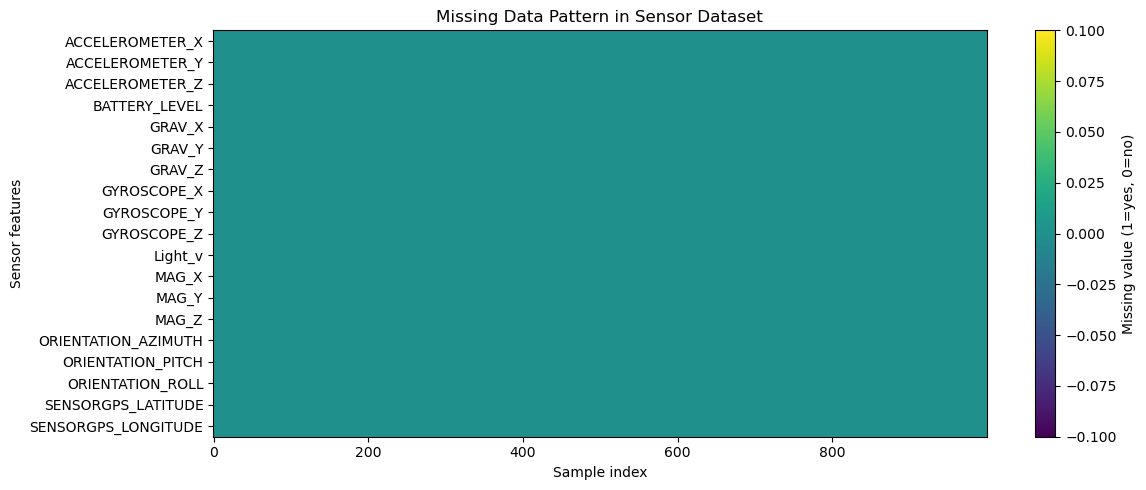

Saved: report_figures/01_missing_data_heatmap.png


In [11]:
sample_cols = numeric_cols[:20]
missing_matrix = df[sample_cols].isna().astype(int).head(1000)

plt.figure(figsize=(12, 5))
plt.imshow(missing_matrix.T, aspect="auto", interpolation="nearest")
plt.yticks(range(len(sample_cols)), sample_cols)
plt.xlabel("Sample index")
plt.ylabel("Sensor features")
plt.title("Missing Data Pattern in Sensor Dataset")
plt.colorbar(label="Missing value (1=yes, 0=no)")
save_fig("01_missing_data_heatmap.png")

## 3. Samples per User / UID

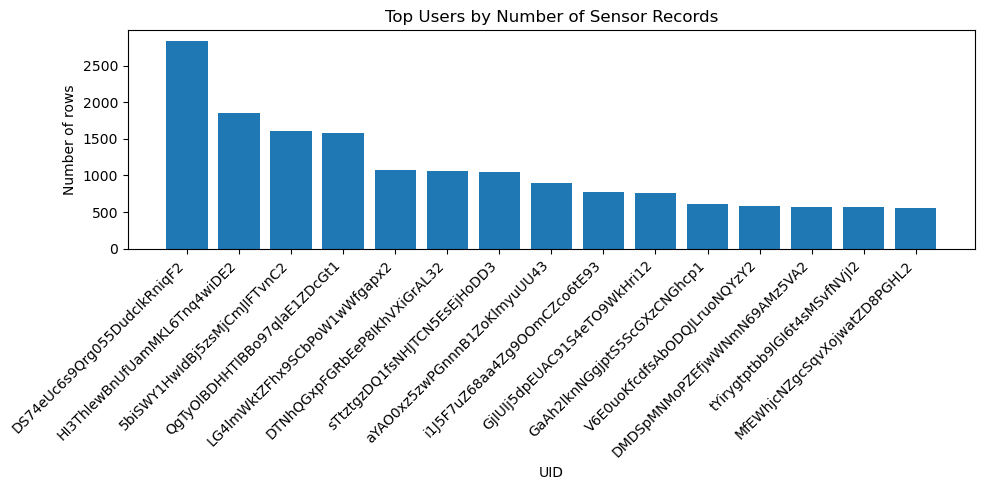

Saved: report_figures/02_uid_sample_distribution.png


In [12]:
uid_counts = df["UID"].value_counts().head(15)

plt.figure(figsize=(10, 5))
plt.bar(uid_counts.index.astype(str), uid_counts.values)
plt.xlabel("UID")
plt.ylabel("Number of rows")
plt.title("Top Users by Number of Sensor Records")
plt.xticks(rotation=45, ha="right")
save_fig("02_uid_sample_distribution.png")

## 4. Accelerometer Time-Series

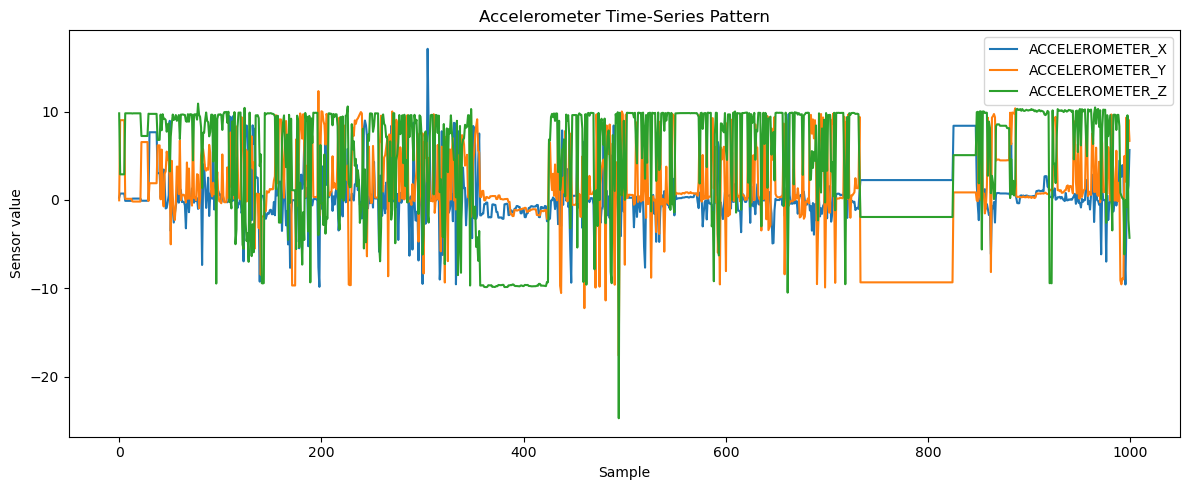

Saved: report_figures/03_accelerometer_time_series.png


In [13]:
acc_cols = [c for c in ["ACCELEROMETER_X", "ACCELEROMETER_Y", "ACCELEROMETER_Z"] if c in df.columns]

if acc_cols:
    sample_df = df[acc_cols].dropna().head(1000)
    plt.figure(figsize=(12, 5))
    for c in acc_cols:
        plt.plot(sample_df[c].values, label=c)
    plt.xlabel("Sample")
    plt.ylabel("Sensor value")
    plt.title("Accelerometer Time-Series Pattern")
    plt.legend()
    save_fig("03_accelerometer_time_series.png")
else:
    print("Accelerometer columns not found.")

## 5. Gyroscope Time-Series

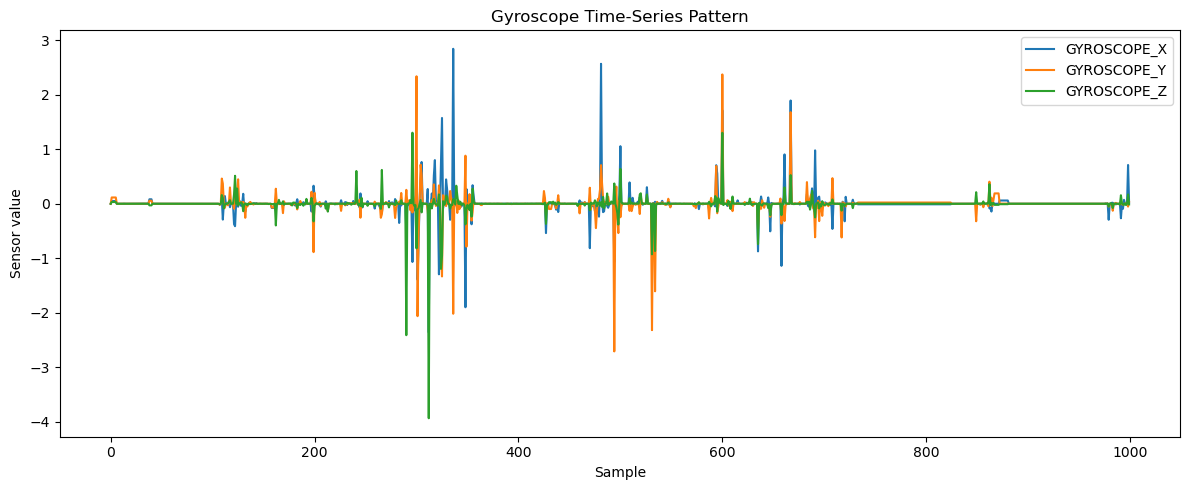

Saved: report_figures/04_gyroscope_time_series.png


In [14]:
gyro_cols = [c for c in ["GYROSCOPE_X", "GYROSCOPE_Y", "GYROSCOPE_Z"] if c in df.columns]

if gyro_cols:
    sample_df = df[gyro_cols].dropna().head(1000)
    plt.figure(figsize=(12, 5))
    for c in gyro_cols:
        plt.plot(sample_df[c].values, label=c)
    plt.xlabel("Sample")
    plt.ylabel("Sensor value")
    plt.title("Gyroscope Time-Series Pattern")
    plt.legend()
    save_fig("04_gyroscope_time_series.png")
else:
    print("Gyroscope columns not found.")

## 6. Sensor Value Distribution Histograms

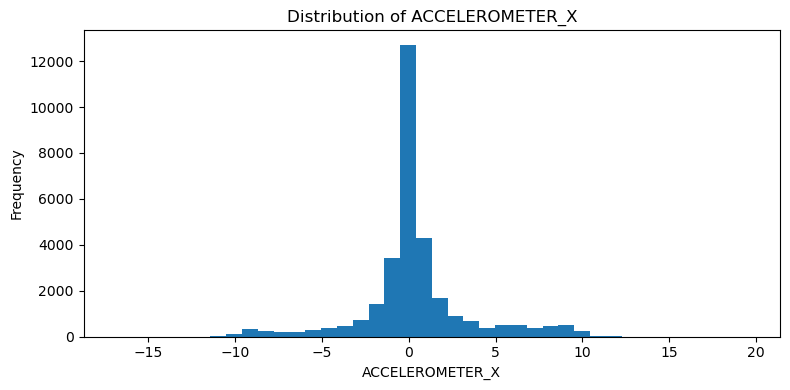

Saved: report_figures/05_distribution_ACCELEROMETER_X.png


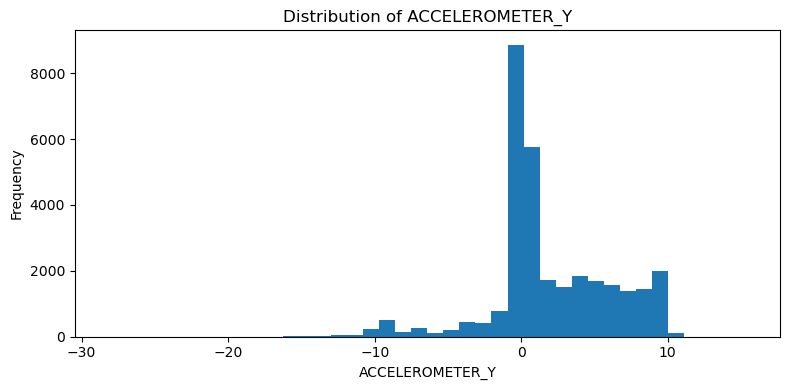

Saved: report_figures/05_distribution_ACCELEROMETER_Y.png


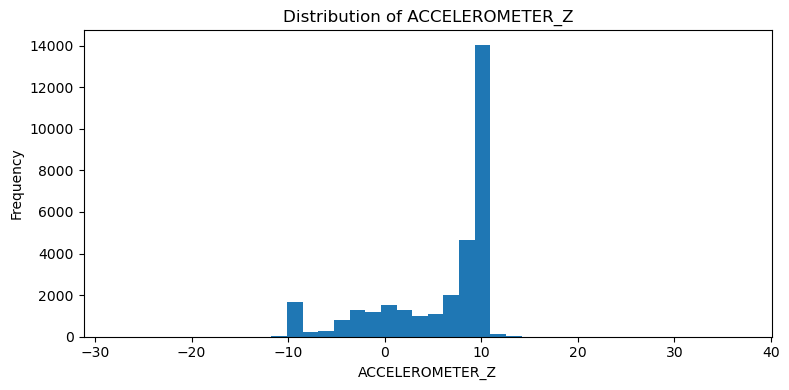

Saved: report_figures/05_distribution_ACCELEROMETER_Z.png


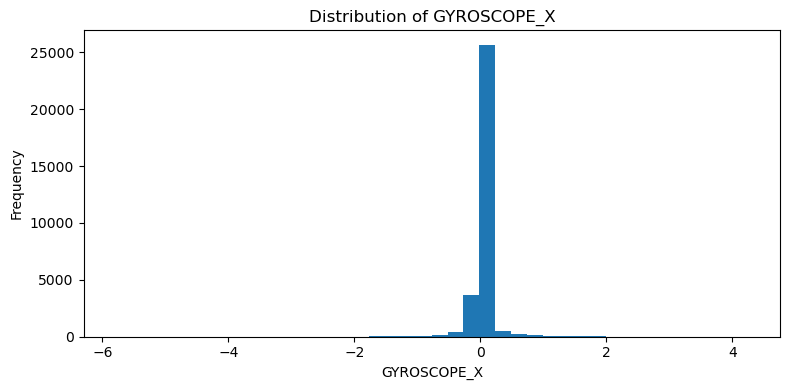

Saved: report_figures/05_distribution_GYROSCOPE_X.png


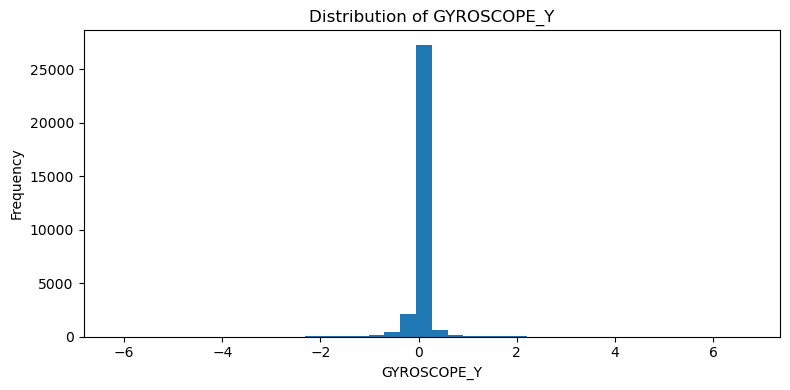

Saved: report_figures/05_distribution_GYROSCOPE_Y.png


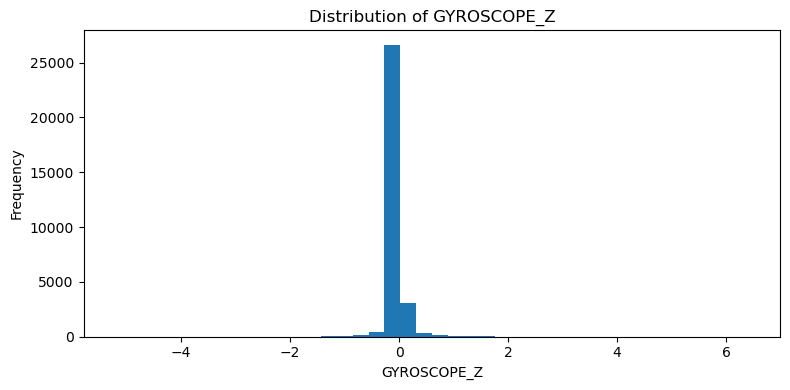

Saved: report_figures/05_distribution_GYROSCOPE_Z.png


In [15]:
plot_cols = acc_cols + gyro_cols

for col in plot_cols:
    values = df[col].dropna().values
    if len(values) == 0:
        continue
    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=40)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    save_fig(f"05_distribution_{col}.png")

## 7. Normal vs Intrusion Boxplots

/var/folders/6c/s7p4dvxs4cn649b9hvv5tbr40000gn/T/ipykernel_83091/3827083146.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Normal", "Intrusion"])


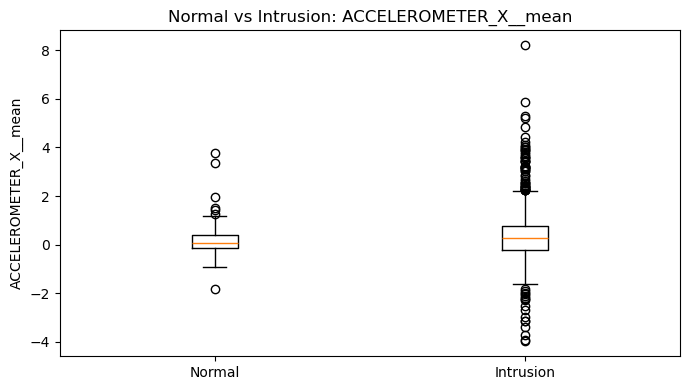

Saved: report_figures/06_boxplot_ACCELEROMETER_X__mean.png


/var/folders/6c/s7p4dvxs4cn649b9hvv5tbr40000gn/T/ipykernel_83091/3827083146.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Normal", "Intrusion"])


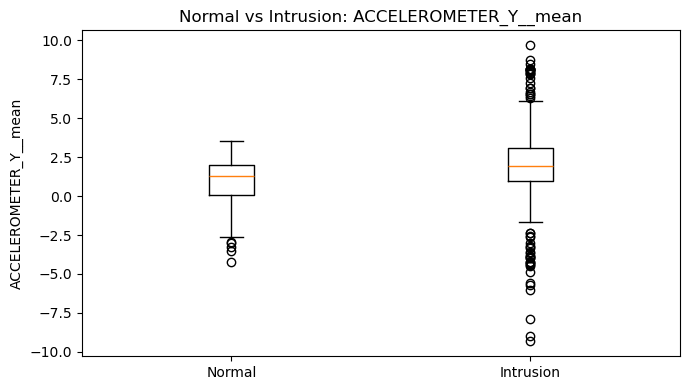

Saved: report_figures/06_boxplot_ACCELEROMETER_Y__mean.png


/var/folders/6c/s7p4dvxs4cn649b9hvv5tbr40000gn/T/ipykernel_83091/3827083146.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Normal", "Intrusion"])


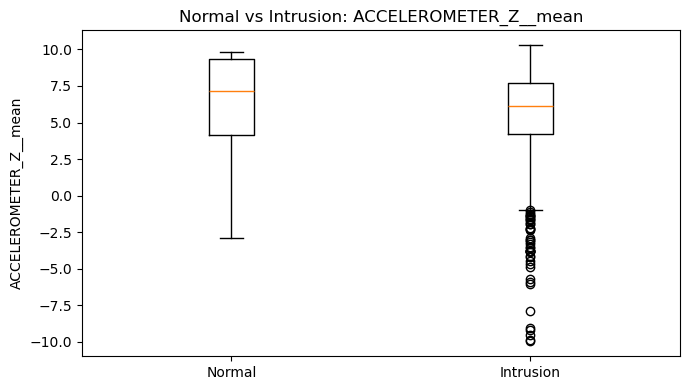

Saved: report_figures/06_boxplot_ACCELEROMETER_Z__mean.png


/var/folders/6c/s7p4dvxs4cn649b9hvv5tbr40000gn/T/ipykernel_83091/3827083146.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Normal", "Intrusion"])


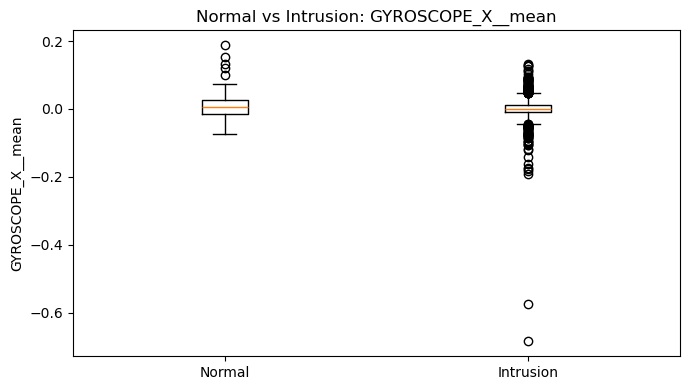

Saved: report_figures/06_boxplot_GYROSCOPE_X__mean.png


/var/folders/6c/s7p4dvxs4cn649b9hvv5tbr40000gn/T/ipykernel_83091/3827083146.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Normal", "Intrusion"])


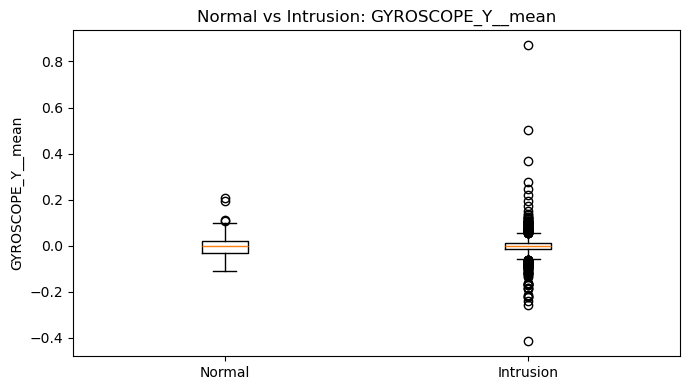

Saved: report_figures/06_boxplot_GYROSCOPE_Y__mean.png


/var/folders/6c/s7p4dvxs4cn649b9hvv5tbr40000gn/T/ipykernel_83091/3827083146.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Normal", "Intrusion"])


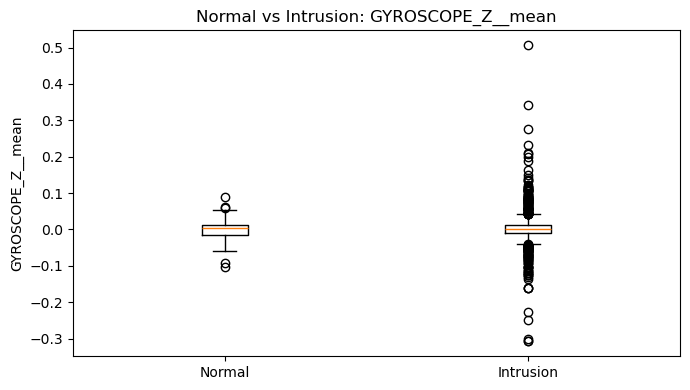

Saved: report_figures/06_boxplot_GYROSCOPE_Z__mean.png


In [16]:
plot_features = []
preferred = [
    "ACCELEROMETER_X__mean", "ACCELEROMETER_Y__mean", "ACCELEROMETER_Z__mean",
    "GYROSCOPE_X__mean", "GYROSCOPE_Y__mean", "GYROSCOPE_Z__mean"
]
for f in preferred:
    if f in X.columns:
        plot_features.append(f)

if not plot_features:
    plot_features = list(X.columns[:6])

df_plot = X[plot_features].copy()
df_plot["label"] = np.where(y == 0, "Normal", "Intrusion")

for feature in plot_features:
    groups = [
        df_plot[df_plot["label"] == "Normal"][feature].dropna().values,
        df_plot[df_plot["label"] == "Intrusion"][feature].dropna().values
    ]
    plt.figure(figsize=(7, 4))
    plt.boxplot(groups, labels=["Normal", "Intrusion"])
    plt.ylabel(feature)
    plt.title(f"Normal vs Intrusion: {feature}")
    safe_name = feature.replace("/", "_").replace(" ", "_")
    save_fig(f"06_boxplot_{safe_name}.png")

## 8. Feature Correlation Heatmap

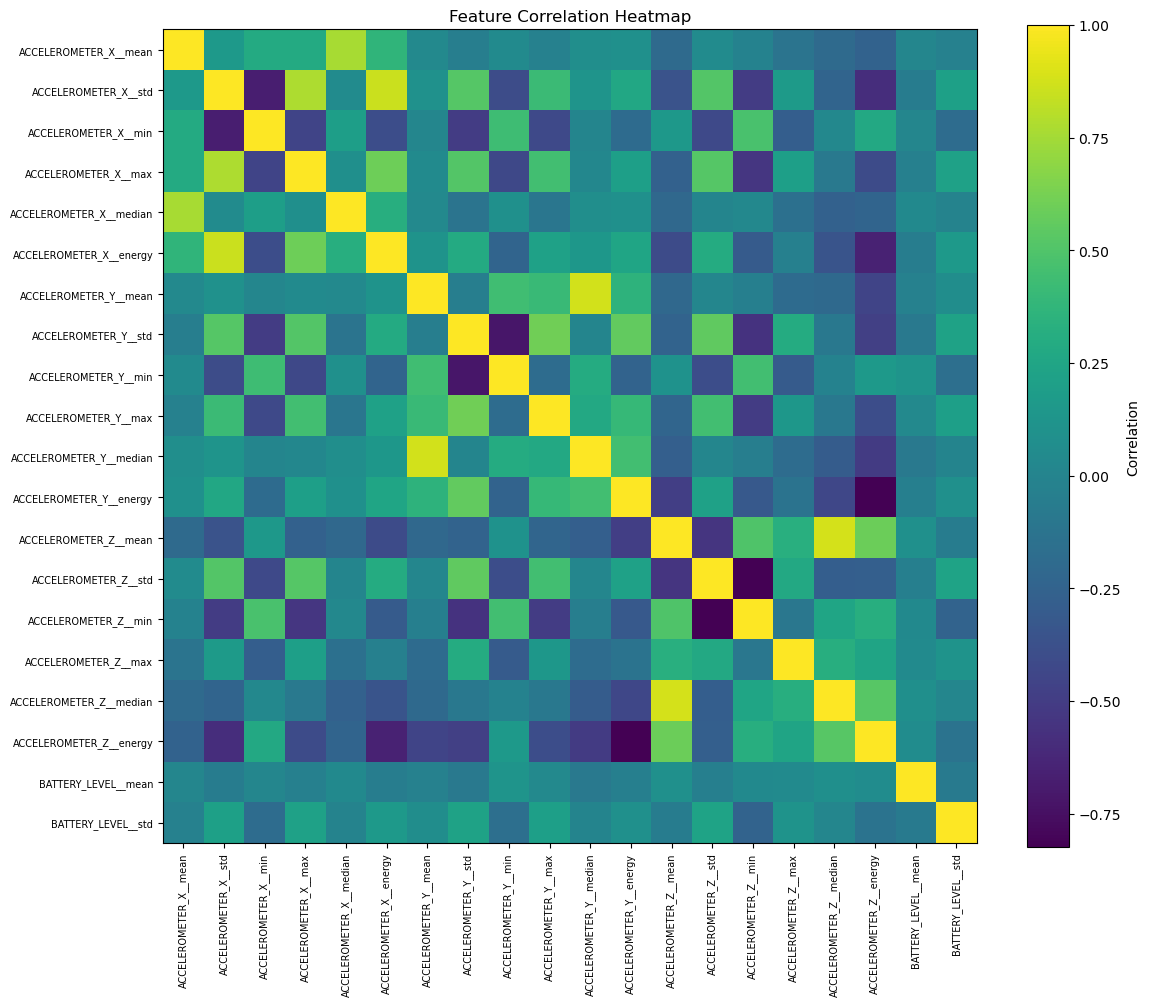

Saved: report_figures/07_feature_correlation_heatmap.png


In [17]:
selected_features = list(X.columns[:20])
corr = X[selected_features].replace([np.inf, -np.inf], np.nan).fillna(0).corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, interpolation="nearest")
plt.colorbar(label="Correlation")
plt.xticks(range(len(selected_features)), selected_features, rotation=90, fontsize=7)
plt.yticks(range(len(selected_features)), selected_features, fontsize=7)
plt.title("Feature Correlation Heatmap")
save_fig("07_feature_correlation_heatmap.png")

## 9. PCA Visualisation: Normal vs Intrusion

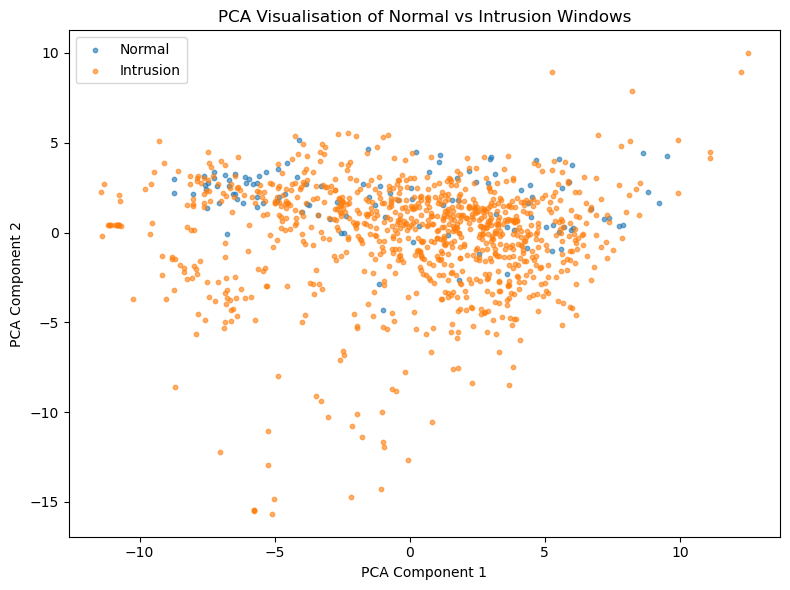

Saved: report_figures/08_pca_normal_vs_intrusion.png


In [18]:
X_clean = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True)).fillna(0)
X_scaled = StandardScaler().fit_transform(X_clean)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
normal_idx = (y == 0)
intr_idx = (y == 1)

plt.scatter(X_pca[normal_idx, 0], X_pca[normal_idx, 1], s=10, alpha=0.6, label="Normal")
plt.scatter(X_pca[intr_idx, 0], X_pca[intr_idx, 1], s=10, alpha=0.6, label="Intrusion")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualisation of Normal vs Intrusion Windows")
plt.legend()
save_fig("08_pca_normal_vs_intrusion.png")

## 10. Required Evaluation Metrics: F1-score, ROC-AUC and Anomaly Detection Success Rate

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, proba_hybrid)

actual_intrusions = (y_test == 1)
if actual_intrusions.sum() > 0:
    anomaly_detection_success_rate = (y_pred[actual_intrusions] == 1).mean()
else:
    anomaly_detection_success_rate = np.nan

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Anomaly Detection Success Rate"],
    "Score": [accuracy, precision, recall, f1, roc_auc, anomaly_detection_success_rate]
})
metrics_df

,Metric,Score
0,Accuracy,0.562264
1,Precision,1.000000
2,Recall,0.510549
3,F1-score,0.675978
4,ROC-AUC,0.957052
5,Anomaly Detection Success Rate,0.510549


## 11. Evaluation Metrics Bar Chart

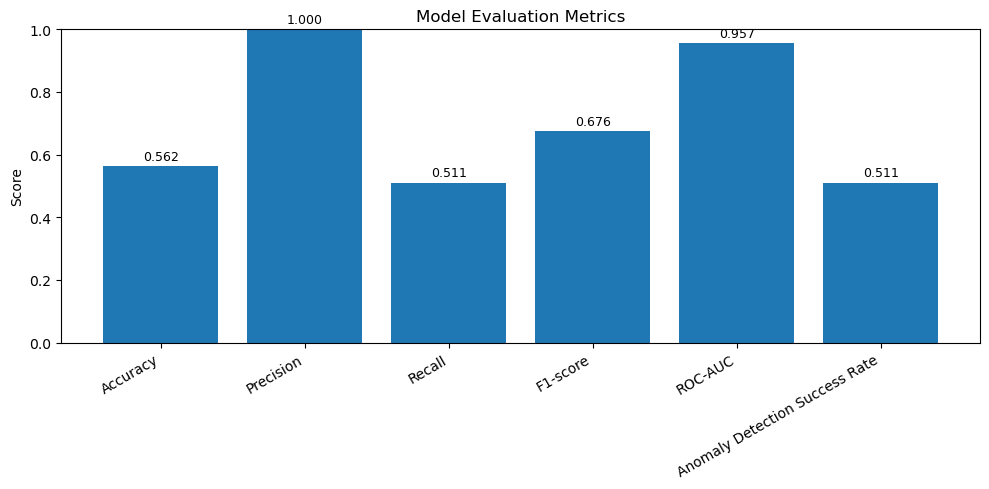

Saved: report_figures/09_evaluation_metrics_bar_chart.png


In [20]:
plt.figure(figsize=(10, 5))
plt.bar(metrics_df["Metric"], metrics_df["Score"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Evaluation Metrics")
plt.xticks(rotation=30, ha="right")

for i, v in enumerate(metrics_df["Score"]):
    if pd.notna(v):
        plt.text(i, min(v + 0.02, 1.02), f"{v:.3f}", ha="center", fontsize=9)

save_fig("09_evaluation_metrics_bar_chart.png")

## 12. Confusion Matrix Diagram

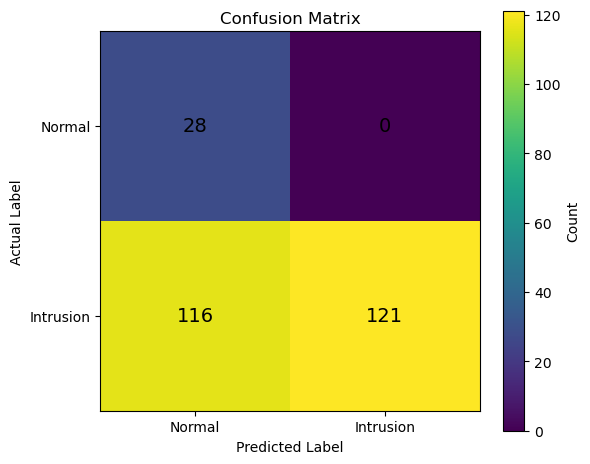

Saved: report_figures/10_confusion_matrix.png


In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar(label="Count")
plt.xticks([0, 1], ["Normal", "Intrusion"])
plt.yticks([0, 1], ["Normal", "Intrusion"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14)

save_fig("10_confusion_matrix.png")

## 13. ROC Curve Diagram

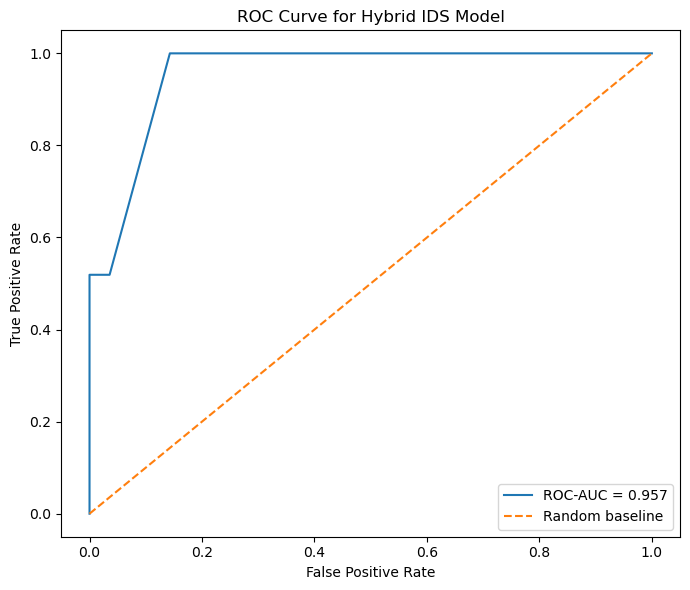

Saved: report_figures/11_roc_curve.png


In [22]:
fpr, tpr, thresholds = roc_curve(y_test, proba_hybrid)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Hybrid IDS Model")
plt.legend()
save_fig("11_roc_curve.png")

## 14. Anomaly Score with Threshold

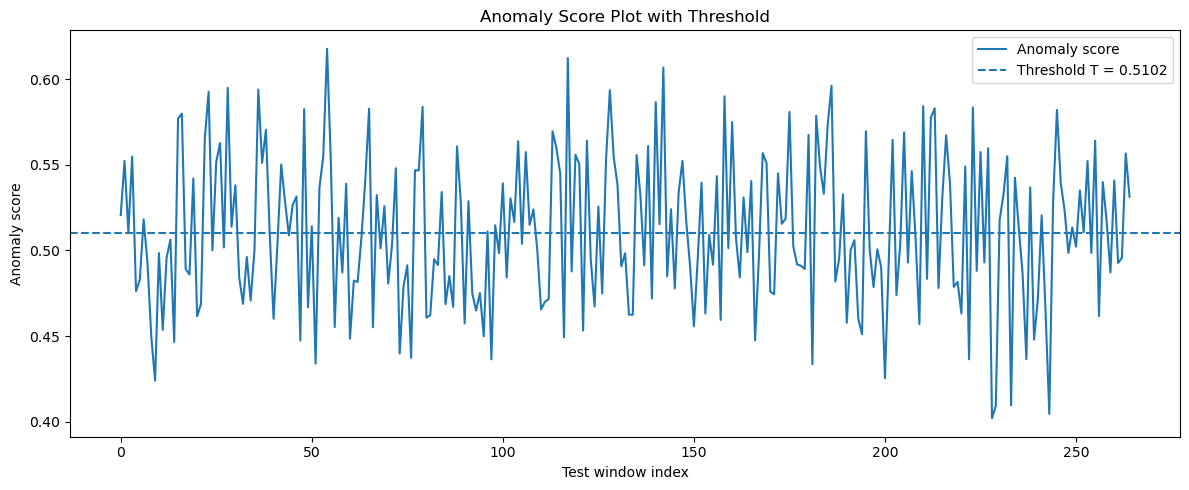

Saved: report_figures/12_anomaly_score_threshold.png


In [23]:
plt.figure(figsize=(12, 5))
plt.plot(test_scores, label="Anomaly score")
plt.axhline(y=T, linestyle="--", label=f"Threshold T = {T:.4f}")
plt.xlabel("Test window index")
plt.ylabel("Anomaly score")
plt.title("Anomaly Score Plot with Threshold")
plt.legend()
save_fig("12_anomaly_score_threshold.png")

## 15. Intrusion Probability Over Time

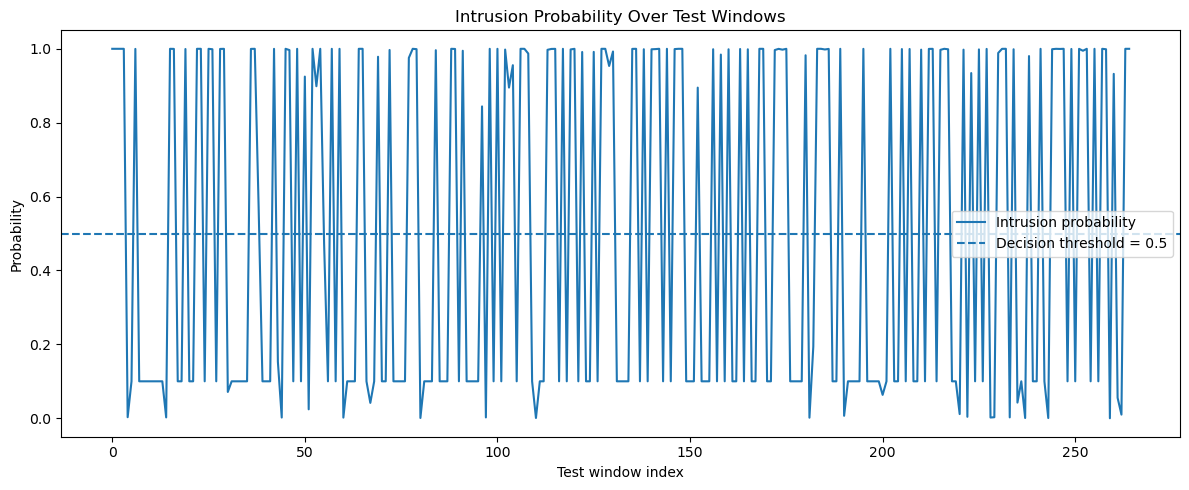

Saved: report_figures/13_intrusion_probability_over_time.png


In [24]:
plt.figure(figsize=(12, 5))
plt.plot(proba_hybrid, label="Intrusion probability")
plt.axhline(y=0.5, linestyle="--", label="Decision threshold = 0.5")
plt.xlabel("Test window index")
plt.ylabel("Probability")
plt.title("Intrusion Probability Over Test Windows")
plt.legend()
save_fig("13_intrusion_probability_over_time.png")

## 16. Feature Importance Diagram

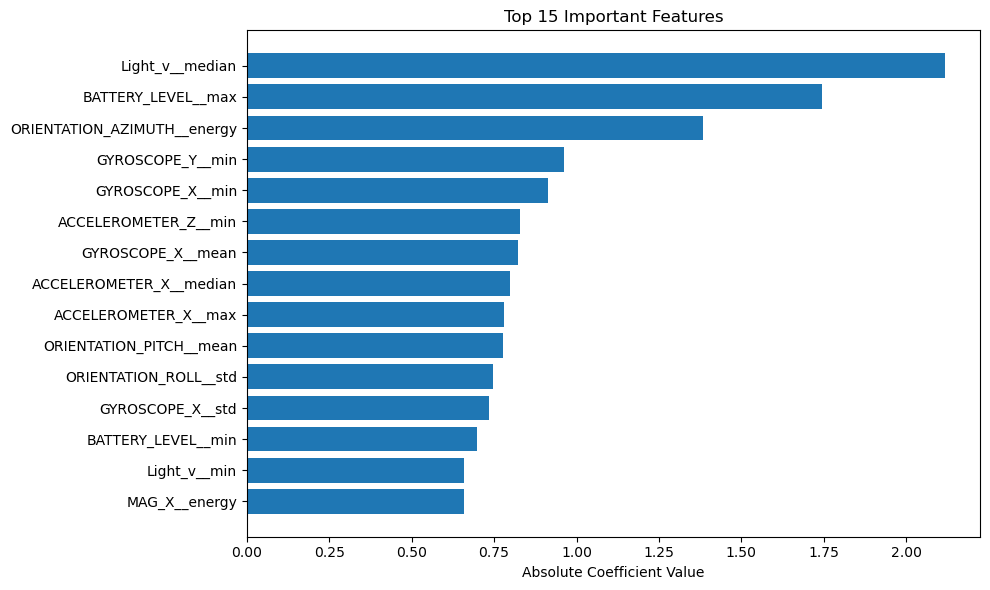

Saved: report_figures/14_feature_importance.png


,Feature,Importance,Coefficient
64,Light_v__median,2.117840,2.117840
21,BATTERY_LEVEL__max,1.744771,1.744771
89,ORIENTATION_AZIMUTH__energy,1.383727,1.383727
50,GYROSCOPE_Y__min,0.961015,0.961015
44,GYROSCOPE_X__min,0.914817,0.914817
14,ACCELEROMETER_Z__min,0.827889,-0.827889
42,GYROSCOPE_X__mean,0.822327,-0.822327
4,ACCELEROMETER_X__median,0.798013,0.798013
3,ACCELEROMETER_X__max,0.778496,0.778496
90,ORIENTATION_PITCH__mean,0.775793,-0.775793


In [25]:
try:
    lr_model = clf.named_steps["lr"]
    coef = lr_model.coef_[0]
    features = np.array(X.columns)

    importance = pd.DataFrame({
        "Feature": features,
        "Importance": np.abs(coef),
        "Coefficient": coef
    }).sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(importance["Feature"][::-1], importance["Importance"][::-1])
    plt.xlabel("Absolute Coefficient Value")
    plt.title("Top 15 Important Features")
    save_fig("14_feature_importance.png")

    display(importance)
except Exception as e:
    print("Could not create feature importance plot:", e)

## 17. Anomaly Detection Success Rate Diagram

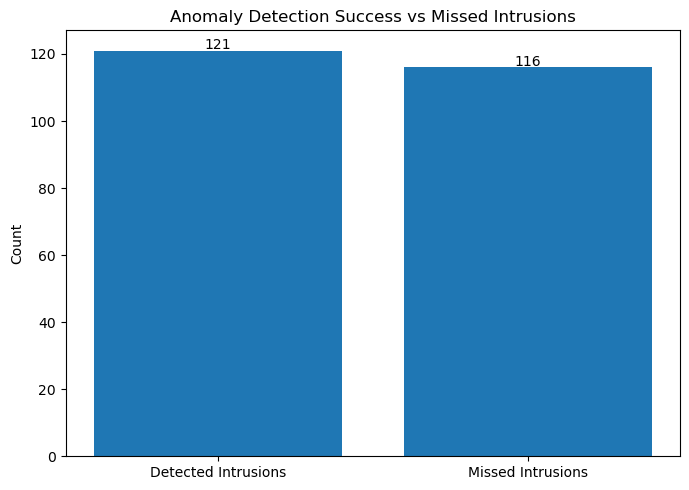

Saved: report_figures/15_anomaly_detection_success_rate.png
Anomaly Detection Success Rate: 0.510548523206751


,Category,Count
0,Detected Intrusions,121
1,Missed Intrusions,116


In [26]:
success_df = pd.DataFrame({
    "Category": ["Detected Intrusions", "Missed Intrusions"],
    "Count": [
        int(((y_test == 1) & (y_pred == 1)).sum()),
        int(((y_test == 1) & (y_pred == 0)).sum())
    ]
})

plt.figure(figsize=(7, 5))
plt.bar(success_df["Category"], success_df["Count"])
plt.ylabel("Count")
plt.title("Anomaly Detection Success vs Missed Intrusions")

for i, v in enumerate(success_df["Count"]):
    plt.text(i, v + 0.5, str(v), ha="center")

save_fig("15_anomaly_detection_success_rate.png")
print("Anomaly Detection Success Rate:", anomaly_detection_success_rate)
success_df

## 18. System Architecture Diagram

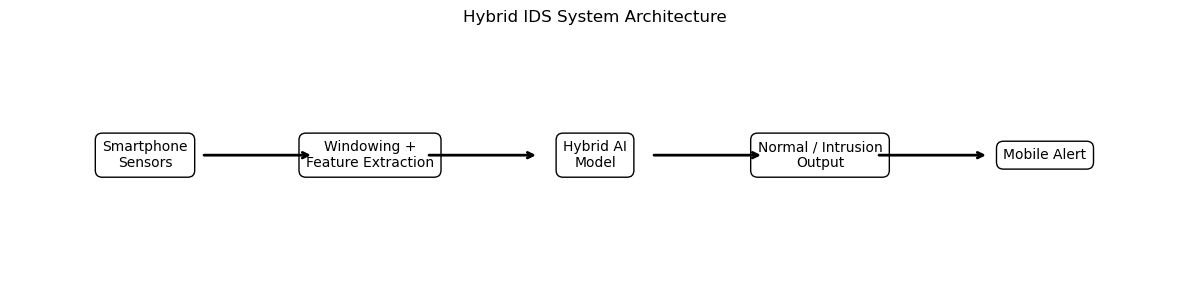

Saved: report_figures/16_system_architecture_diagram.png


In [27]:
plt.figure(figsize=(12, 3))
steps = ["Smartphone\nSensors", "Windowing +\nFeature Extraction", "Hybrid AI\nModel", "Normal / Intrusion\nOutput", "Mobile Alert"]

for x, label in enumerate(steps):
    plt.text(x, 0, label, ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black"))

for i in range(len(steps)-1):
    plt.annotate("", xy=(i+0.75, 0), xytext=(i+0.25, 0),
                 arrowprops=dict(arrowstyle="->", lw=2))

plt.xlim(-0.6, len(steps)-0.4)
plt.ylim(-1, 1)
plt.axis("off")
plt.title("Hybrid IDS System Architecture")
save_fig("16_system_architecture_diagram.png")

## 19. Mobile App Workflow Diagram

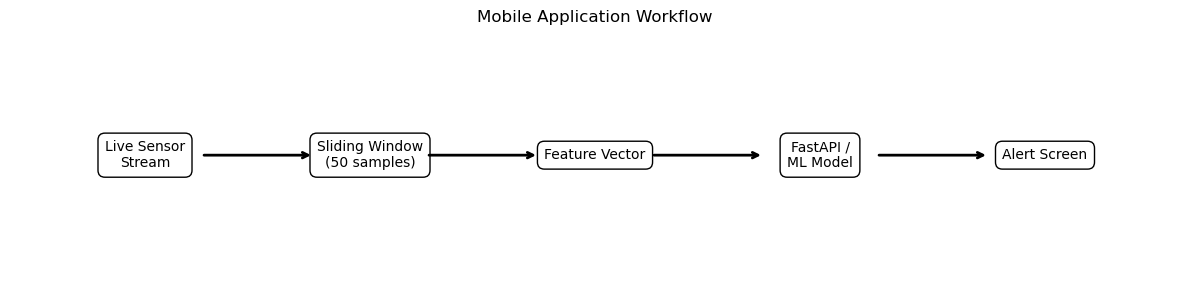

Saved: report_figures/17_mobile_app_workflow_diagram.png


In [28]:
plt.figure(figsize=(12, 3))
steps = ["Live Sensor\nStream", "Sliding Window\n(50 samples)", "Feature Vector", "FastAPI /\nML Model", "Alert Screen"]

for x, label in enumerate(steps):
    plt.text(x, 0, label, ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black"))

for i in range(len(steps)-1):
    plt.annotate("", xy=(i+0.75, 0), xytext=(i+0.25, 0),
                 arrowprops=dict(arrowstyle="->", lw=2))

plt.xlim(-0.6, len(steps)-0.4)
plt.ylim(-1, 1)
plt.axis("off")
plt.title("Mobile Application Workflow")
save_fig("17_mobile_app_workflow_diagram.png")

## 20. Report Figure Captions

In [29]:
captions = [
    ("Figure 1", "Missing Data Pattern in Sensor Dataset — shows missing values across selected sensor features before preprocessing."),
    ("Figure 2", "Top Users by Number of Sensor Records — shows sample distribution across UIDs."),
    ("Figure 3", "Accelerometer Time-Series Pattern — illustrates motion changes captured by accelerometer sensors."),
    ("Figure 4", "Gyroscope Time-Series Pattern — illustrates rotation changes captured by gyroscope sensors."),
    ("Figure 5", "Sensor Value Distributions — shows how raw sensor readings are distributed before modelling."),
    ("Figure 6", "Normal vs Intrusion Comparison — compares feature distributions between normal and intrusion samples."),
    ("Figure 7", "Feature Correlation Heatmap — shows relationships between extracted features."),
    ("Figure 8", "PCA Visualisation — reduces extracted features into two dimensions to inspect class separation."),
    ("Figure 9", "Evaluation Metrics Bar Chart — compares accuracy, precision, recall, F1-score, ROC-AUC and anomaly detection success rate."),
    ("Figure 10", "Confusion Matrix — shows correct and incorrect predictions for normal and intrusion classes."),
    ("Figure 11", "ROC Curve — evaluates the model’s ability to distinguish normal and intrusion behaviour."),
    ("Figure 12", "Anomaly Score Plot — shows anomaly scores with the selected decision threshold."),
    ("Figure 13", "Intrusion Probability Over Time — shows intrusion probability across test windows."),
    ("Figure 14", "Feature Importance — identifies the features that most influence the classifier."),
    ("Figure 15", "Anomaly Detection Success Rate — shows detected and missed intrusion samples."),
    ("Figure 16", "Hybrid IDS System Architecture — explains the overall system flow."),
    ("Figure 17", "Mobile Application Workflow — explains real-time detection in the Flutter app."),
]
caption_df = pd.DataFrame(captions, columns=["Figure", "Caption"])
caption_df

,Figure,Caption
0,Figure 1,Missing Data Pattern in Sensor Dataset — shows...
1,Figure 2,Top Users by Number of Sensor Records — shows ...
2,Figure 3,Accelerometer Time-Series Pattern — illustrate...
3,Figure 4,Gyroscope Time-Series Pattern — illustrates ro...
4,Figure 5,Sensor Value Distributions — shows how raw sen...
5,Figure 6,Normal vs Intrusion Comparison — compares feat...
6,Figure 7,Feature Correlation Heatmap — shows relationsh...
7,Figure 8,PCA Visualisation — reduces extracted features...
8,Figure 9,Evaluation Metrics Bar Chart — compares accura...
9,Figure 10,Confusion Matrix — shows correct and incorrect...
